### 1D Gradient Descent

Lets assume the a function $f(x) = 3x^2 -3x + 4$

The derivative would be $\frac{df(x)}{dx} = 6x -3$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def fx(x):
    return 3*x**2 -3*x + 4

def deriv(x):
    return 6*x -3

In [3]:
x = np.linspace(-2, 5, 500)

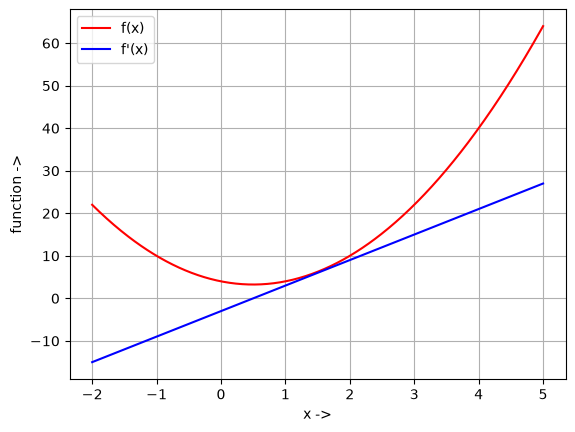

In [5]:
plt.plot(x, fx(x), color='r', label='f(x)')
plt.plot(x, deriv(x), color='b', label="f'(x)")

plt.xlabel('x ->')
plt.ylabel('function ->')

plt.legend()
plt.grid()
plt.show()

### Finding th the minimum of the function using Gradient Descent

In [18]:
# start with random vale or assumption
local_min = np.random.choice(x, 1)
print(f"Starting lcoal minima: {local_min}")

epochs = 100
learning_rate = 0.01

model_params = np.zeros((epochs, 2))
for i in range(epochs):
    step = learning_rate * deriv(local_min)  # the slope * derivative is called step in gradient descent
    local_min = local_min - step
    model_params[i, 0] = local_min[0]
    model_params[i, 1] = deriv(local_min)[0]

print(f"Ending lcoal minima: {local_min}")

Starting lcoal minima: [0.28657315]
Ending lcoal minima: [0.49956143]


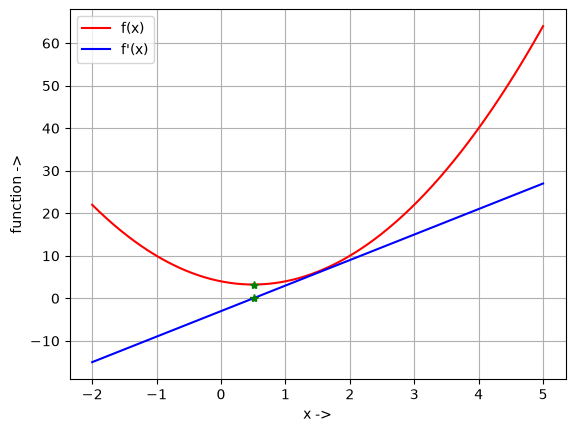

In [12]:
plt.plot(x, fx(x), color='r', label='f(x)')
plt.plot(local_min, fx(local_min), marker='*', color='g')
plt.plot(x, deriv(x), color='b', label="f'(x)")
plt.plot(local_min, deriv(local_min), marker='*', color='g')

plt.xlabel('x ->')
plt.ylabel('function ->')

plt.legend()
plt.grid()
plt.show()

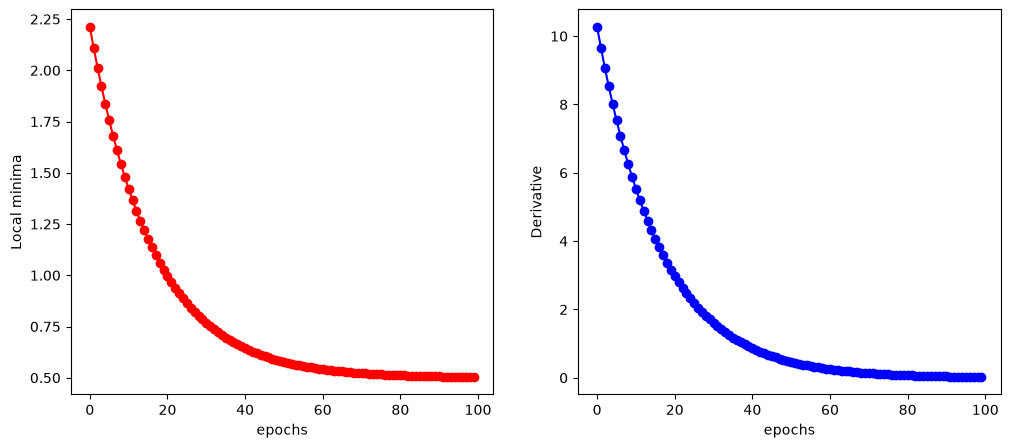

In [10]:
# how the derivative and local minima is varying?


fig, ax = plt.subplots(figsize=(12, 5), nrows=1, ncols=2)

ax[0].plot(model_params[:, 0], 'o-', color='r')
ax[0].set_xlabel('epochs')
ax[0].set_ylabel('Local minima')

ax[1].plot(model_params[:, 1], 'o-', color='b')
ax[1].set_xlabel('epochs')
ax[1].set_ylabel('Derivative')

plt.show()

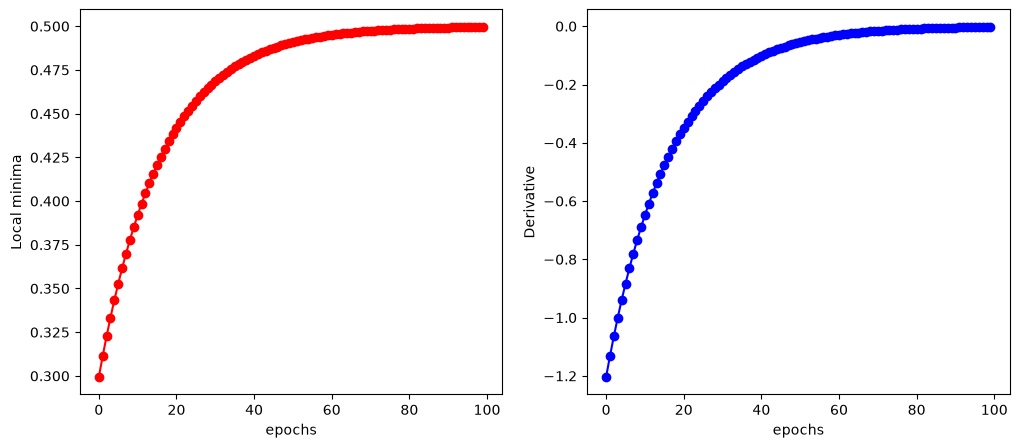

In [19]:
# how the derivative and local minima is varying?


fig, ax = plt.subplots(figsize=(12, 5), nrows=1, ncols=2)

ax[0].plot(model_params[:, 0], 'o-', color='r')
ax[0].set_xlabel('epochs')
ax[0].set_ylabel('Local minima')

ax[1].plot(model_params[:, 1], 'o-', color='b')
ax[1].set_xlabel('epochs')
ax[1].set_ylabel('Derivative')

plt.show()

In [39]:
# start with random vale or assumption
def gd(lr: float, epochs: int, local_min: float): 
    
    print(f"Learning Rate: {lr}")
    print(f"\tStarting lcoal minima: {local_min}")
    
    model_params = np.zeros((epochs, 2))
    for i in range(epochs):
        step = lr * deriv(local_min)  # the slope * derivative is called step in gradient descent
        local_min = local_min - step
        model_params[i, 0] = local_min[0]
        model_params[i, 1] = deriv(local_min)[0]
    
    print(f"\tEnding lcoal minima: {local_min}")
    return model_params

### Experiment with different learnining rate

In [40]:
exp_results = {}
local_min = np.random.choice(x, 1)
for lr in np.logspace(-1, -4, 4):
    exp_results[f'lr_{lr}'] = gd(lr, 100, local_min)    

Learning Rate: 0.1
	Starting lcoal minima: [3.24649299]
	Ending lcoal minima: [0.5]
Learning Rate: 0.01
	Starting lcoal minima: [3.24649299]
	Ending lcoal minima: [0.5056437]
Learning Rate: 0.001
	Starting lcoal minima: [3.24649299]
	Ending lcoal minima: [2.00458571]
Learning Rate: 0.0001
	Starting lcoal minima: [3.24649299]
	Ending lcoal minima: [3.08650311]


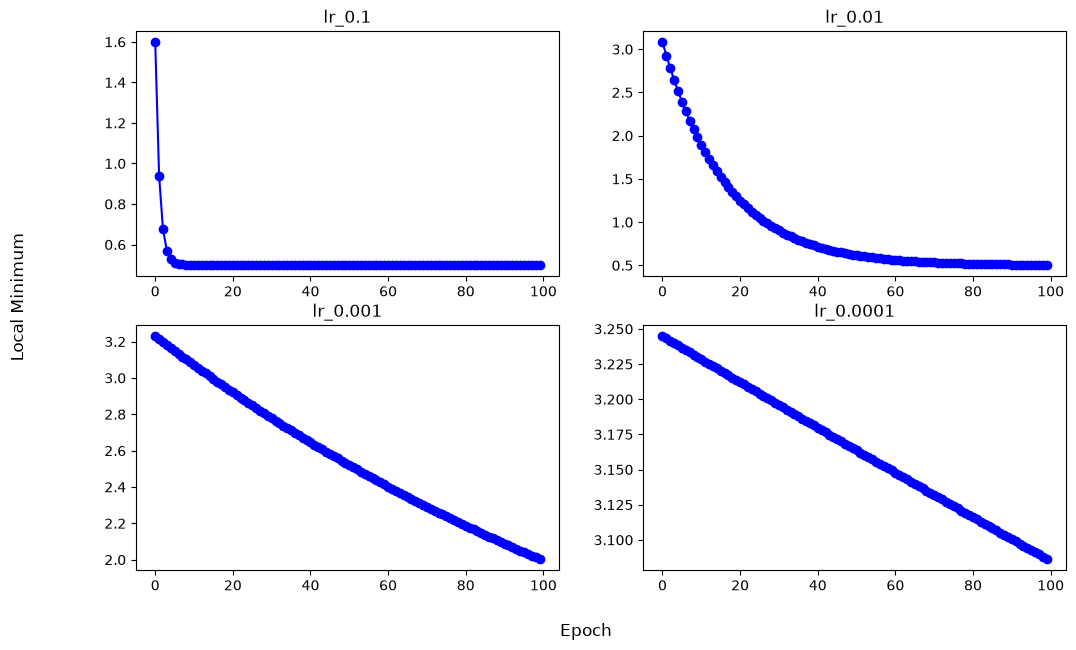

In [43]:
fig, ax = plt.subplots(figsize=(12, 7), nrows=2, ncols=2)

ax = ax.flatten()

for i, (exp, values) in enumerate(exp_results.items()):
    ax[i].plot(values[:, 0], 'o-', color='b')
    ax[i].set_title(exp)
    
fig.supxlabel('Epoch')
fig.supylabel('Local Minimum')
plt.show()

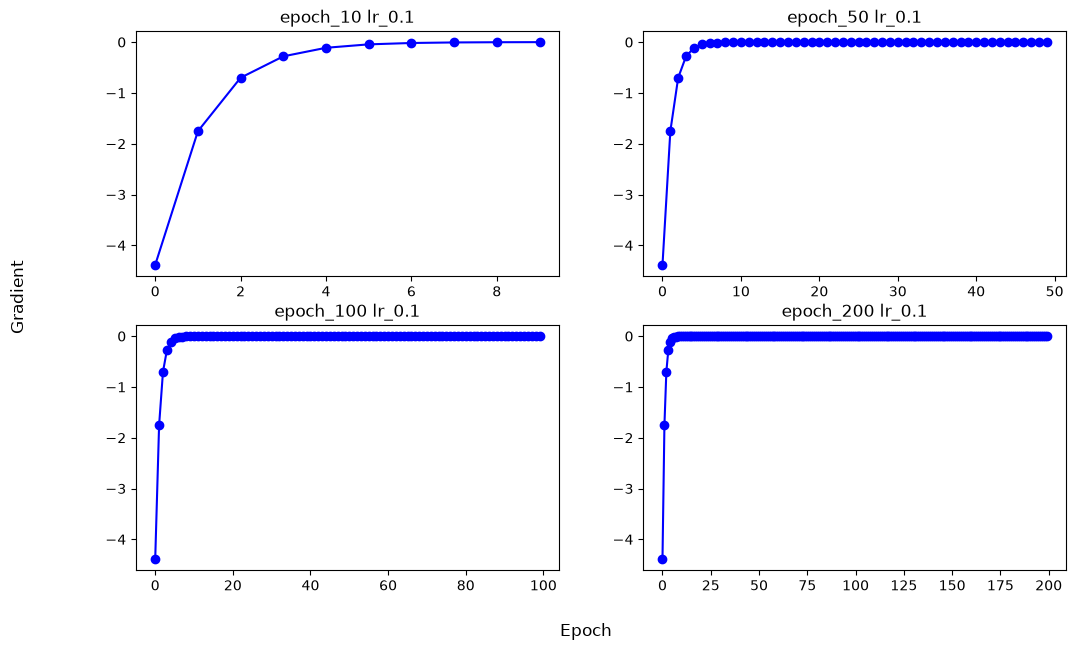

In [47]:
fig, ax = plt.subplots(figsize=(12, 7), nrows=2, ncols=2)

ax = ax.flatten()

for i, (exp, values) in enumerate(exp_results.items()):
    ax[i].plot(values[:, 1], 'o-', color='b')
    ax[i].set_title(exp)
    
fig.supxlabel('Epoch')
fig.supylabel('Gradient')
plt.show()

### Experiment with different epochs

In [44]:
exp_results = {}
local_min = np.random.choice(x, 1)
lr = 0.1
for epoch in [10, 50, 100, 200]:
    exp_results[f'epoch_{epoch} lr_{lr}'] = gd(lr, epoch, local_min)   

Learning Rate: 0.1
	Starting lcoal minima: [-1.32665331]
	Ending lcoal minima: [0.49980846]
Learning Rate: 0.1
	Starting lcoal minima: [-1.32665331]
	Ending lcoal minima: [0.5]
Learning Rate: 0.1
	Starting lcoal minima: [-1.32665331]
	Ending lcoal minima: [0.5]
Learning Rate: 0.1
	Starting lcoal minima: [-1.32665331]
	Ending lcoal minima: [0.5]


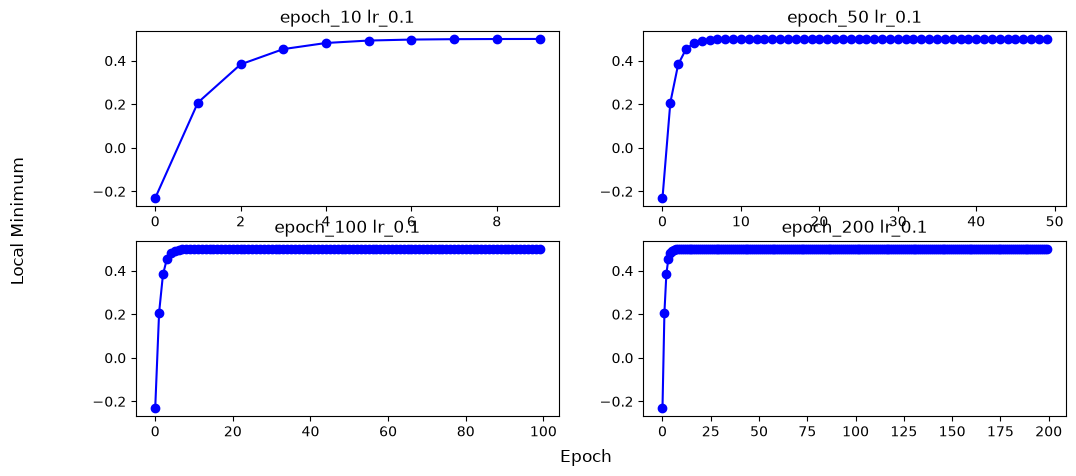

In [45]:
fig, ax = plt.subplots(figsize=(12, 5), nrows=2, ncols=2)

ax = ax.flatten()

for i, (exp, values) in enumerate(exp_results.items()):
    ax[i].plot(values[:, 0], 'o-', color='b')
    ax[i].set_title(exp)
fig.supxlabel('Epoch')
fig.supylabel('Local Minimum')    

plt.show()

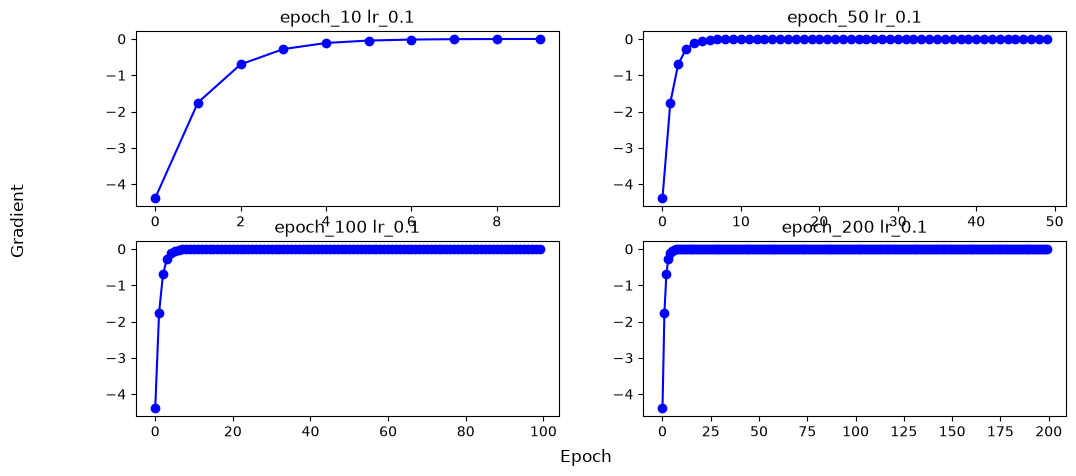

In [46]:
fig, ax = plt.subplots(figsize=(12, 5), nrows=2, ncols=2)

ax = ax.flatten()

for i, (exp, values) in enumerate(exp_results.items()):
    ax[i].plot(values[:, 1], 'o-', color='b')
    ax[i].set_title(exp)
fig.supxlabel('Epoch')
fig.supylabel('Gradient')    

plt.show()